# Heart Disease Prediction Using Machine Learning
### Academic Mini-Project (TAE-2) — Cleveland Database Analysis
**Author:** B.Tech Machine Learning Project  
**Tech Stack:** Python 3, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn  

---

## 1. Problem Statement
Cardiovascular diseases (CVDs) are the leading cause of mortality worldwide. Early detection and risk stratification can enable timely clinical interventions. 

The objective of this mini-project is to build, evaluate, and compare standard supervised machine learning models to classify the presence or absence of coronary heart disease based on clinical and non-invasive diagnostic attributes from the authentic **UCI Cleveland Heart Disease dataset**.

> **Academic & Medical Disclaimer:**  
> This project and notebook are strictly designed for undergraduate educational and academic evaluation purposes. It is **not a medical diagnostic device**, and predictions should not be used as a substitute for professional medical diagnosis.

## 2. Dataset Description
We use the authentic **303-instance Cleveland database** from the UCI Machine Learning Repository.

The dataset includes 14 core clinical attributes:
1. ge: Age in years
2. sex: Sex (1 = Male; 0 = Female)
3. cp: Chest pain type (1 = Typical Angina, 2 = Atypical Angina, 3 = Non-anginal pain, 4 = Asymptomatic)
4. 	restbps: Resting blood pressure on hospital admission (in mm Hg)
5. chol: Serum cholesterol in mg/dl
6. bs: Fasting blood sugar > 120 mg/dl (1 = True, 0 = False)
7. 
estecg: Resting electrocardiographic results (0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy)
8. 	halach: Maximum heart rate achieved during exercise
9. xang: Exercise-induced angina (1 = Yes, 0 = No)
10. oldpeak: ST depression induced by exercise relative to rest
11. slope: Slope of peak exercise ST segment (1 = Upsloping, 2 = Flat, 3 = Downsloping)
12. ca: Number of major vessels (0–3) colored by fluoroscopy
13. 	hal: Thalassemia defect status (3 = Normal, 6 = Fixed defect, 7 = Reversible defect)
14. 
um: Angiographic disease status (diagnosis target: 0 = Absence, 1–4 = Presence)

## 3. Data Loading
We load the raw data directly from the UCI archive or the preserved local copy at data/raw/processed.cleveland.data. Missing values are denoted by '?' in the raw data and are parsed explicitly as NaN.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (8, 5)

project_dir = os.path.abspath('..')
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
from src.data_loader import fetch_raw_data, load_raw_dataset, prepare_dataset, COLUMN_NAMES

raw_df = load_raw_dataset('../data/raw/processed.cleveland.data')
print(f'Raw data shape: {raw_df.shape}')
raw_df.head()

Raw data shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 4. Data Inspection
We inspect the dataset's summary statistics, data types, duplicate rows, and schema integrity.

In [2]:
print('Dataset Information:')
print(raw_df.info())
duplicates = raw_df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
print('Descriptive Summary:')
raw_df.describe().round(2)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None
Duplicate rows: 0
Descriptive Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.94
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00


## 5. Missing-Value Analysis
In the original UCI Cleveland database, missing values are present in two discrete attributes: ca (number of major vessels) and 	hal (thalassemia). We analyze their frequencies.

In [3]:
missing_counts = raw_df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
print('Missing values per column:')
for col, cnt in missing_cols.items():
    print(f'  - {col}: {cnt} missing ({cnt/len(raw_df)*100:.2f}%)')
total_missing_rows = raw_df.isnull().any(axis=1).sum()
print(f'Total rows with missing values: {total_missing_rows} / {len(raw_df)}')

Missing values per column:
  - ca: 4 missing (1.32%)
  - thal: 2 missing (0.66%)
Total rows with missing values: 6 / 303


## 6. Target Transformation
The original target attribute 
um contains values from 0 to 4. We transform it into a binary classification target:
- 
um == 0 -> 0 (No Heart Disease)
- 
um in [1, 2, 3, 4] -> 1 (Heart Disease Present)

In [4]:
df = raw_df.copy()
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])
print(f'Processed dataset shape: {df.shape}')
df.head()

Processed dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 7. Class Distribution
We examine the distribution of the binary target variable to evaluate class balance.

Class 0 (Absent):  164 (54.13%)
Class 1 (Present): 139 (45.87%)


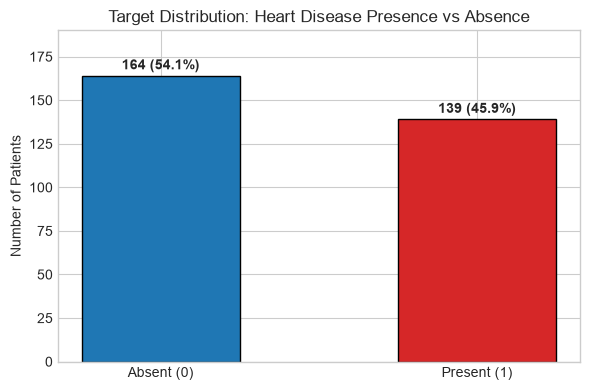

In [5]:
counts = df['target'].value_counts()
pcts = df['target'].value_counts(normalize=True) * 100
print(f'Class 0 (Absent):  {counts[0]} ({pcts[0]:.2f}%)')
print(f'Class 1 (Present): {counts[1]} ({pcts[1]:.2f}%)')

plt.figure(figsize=(6, 4))
colors = ['#1f77b4', '#d62728']
bars = plt.bar(['Absent (0)', 'Present (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, y + 2, f'{y} ({y/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
plt.title('Target Distribution: Heart Disease Presence vs Absence', fontsize=12)
plt.ylabel('Number of Patients')
plt.ylim(0, 190)
plt.tight_layout()
plt.show()

**Interpretation:**  
The dataset contains 164 negative cases (54.1%) and 139 positive cases (45.9%). Since the classes are relatively balanced, stratified sampling is used to maintain identical class proportions across train/test splits and cross-validation folds.

## 8. Exploratory Data Analysis (EDA)
We examine the diagnostic features in detail through bivariate distributions.
*Note: Statistical associations indicate sample correlations, not clinical causality.*

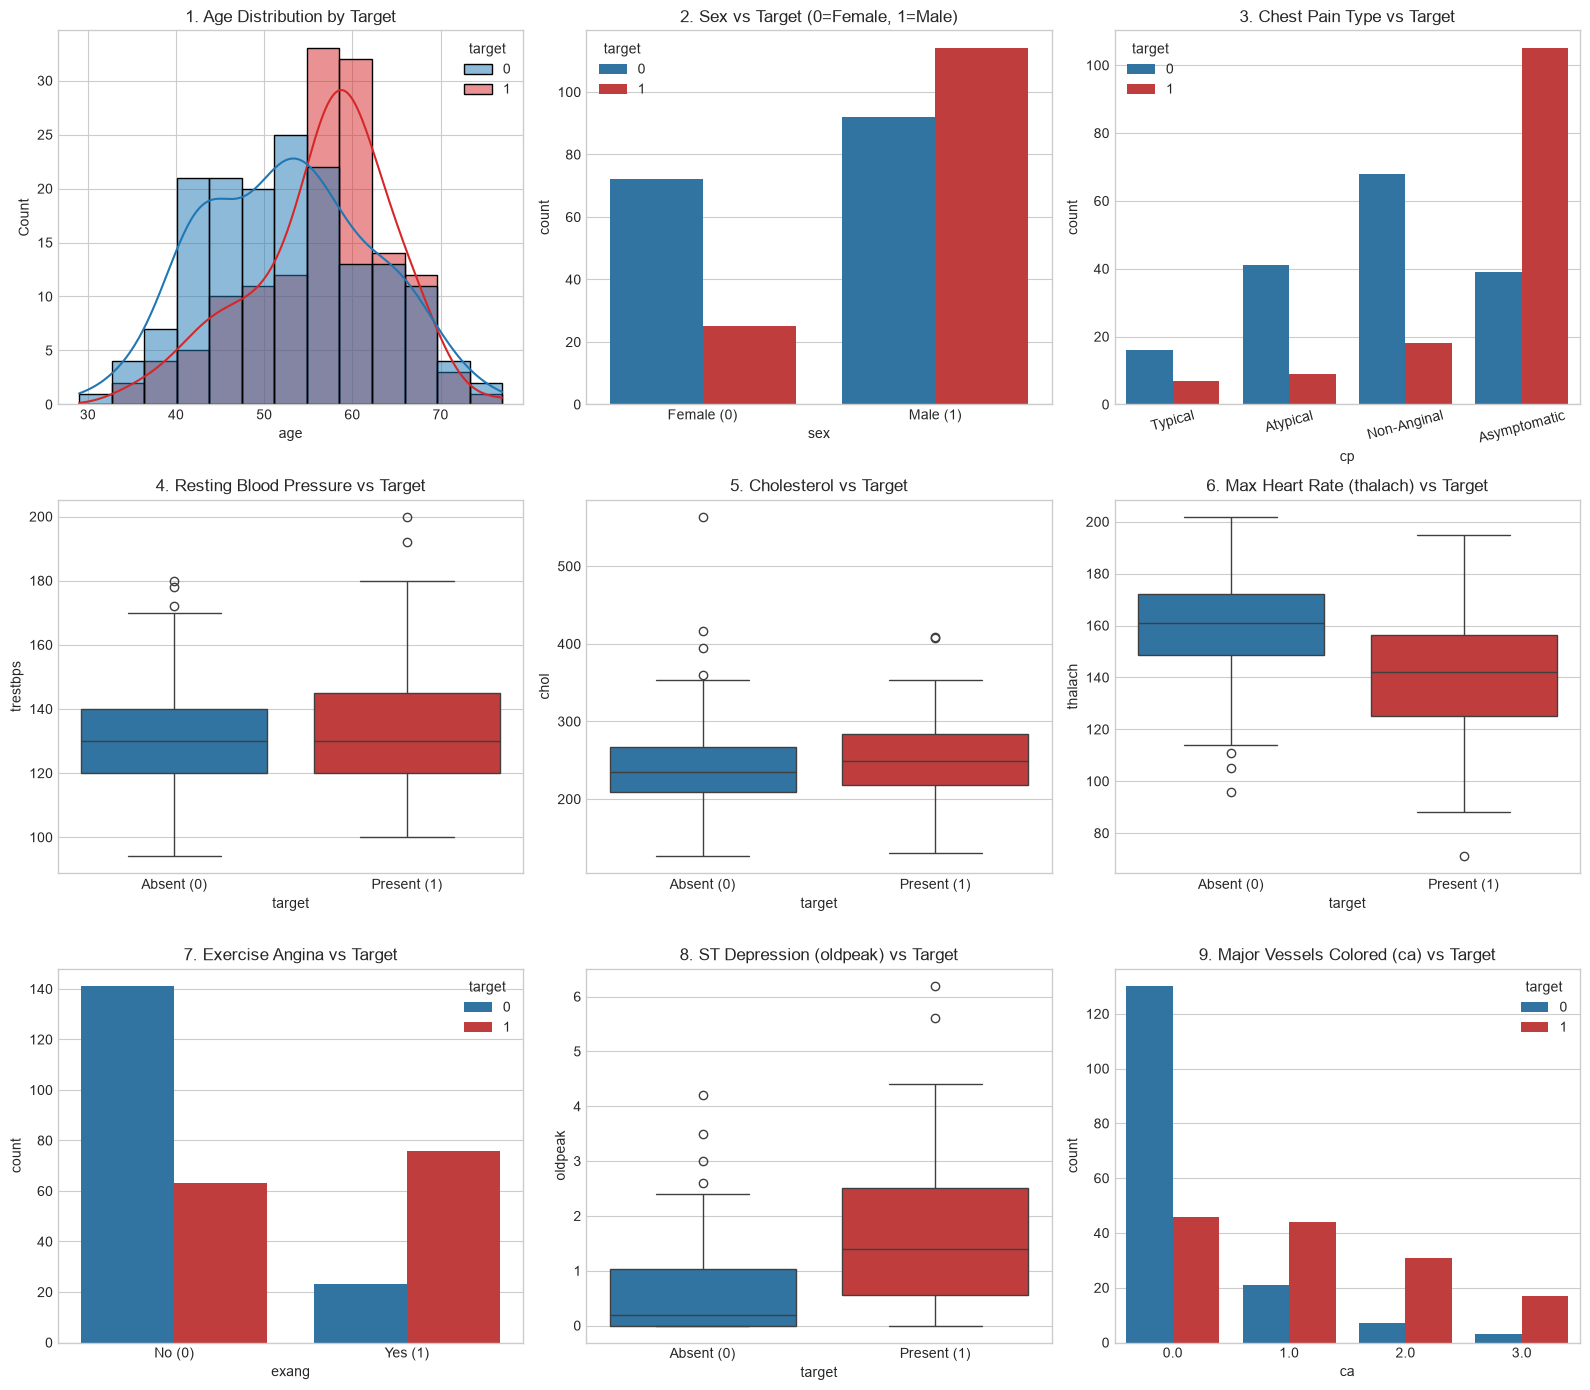

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
colors = ['#1f77b4', '#d62728']

# 1. Age
sns.histplot(data=df, x='age', hue='target', kde=True, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title('1. Age Distribution by Target')

# 2. Sex
sns.countplot(data=df, x='sex', hue='target', palette=colors, ax=axes[0, 1])
axes[0, 1].set_title('2. Sex vs Target (0=Female, 1=Male)')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Female (0)', 'Male (1)'])

# 3. Chest Pain Type
sns.countplot(data=df, x='cp', hue='target', palette=colors, ax=axes[0, 2])
axes[0, 2].set_title('3. Chest Pain Type vs Target')
axes[0, 2].set_xticks([0, 1, 2, 3])
axes[0, 2].set_xticklabels(['Typical', 'Atypical', 'Non-Anginal', 'Asymptomatic'], rotation=15)

# 4. Resting Blood Pressure
sns.boxplot(data=df, x='target', y='trestbps', hue='target', palette=colors, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('4. Resting Blood Pressure vs Target')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Absent (0)', 'Present (1)'])

# 5. Serum Cholesterol
sns.boxplot(data=df, x='target', y='chol', hue='target', palette=colors, legend=False, ax=axes[1, 1])
axes[1, 1].set_title('5. Cholesterol vs Target')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Absent (0)', 'Present (1)'])

# 6. Max Heart Rate
sns.boxplot(data=df, x='target', y='thalach', hue='target', palette=colors, legend=False, ax=axes[1, 2])
axes[1, 2].set_title('6. Max Heart Rate (thalach) vs Target')
axes[1, 2].set_xticks([0, 1])
axes[1, 2].set_xticklabels(['Absent (0)', 'Present (1)'])

# 7. Exercise Angina
sns.countplot(data=df, x='exang', hue='target', palette=colors, ax=axes[2, 0])
axes[2, 0].set_title('7. Exercise Angina vs Target')
axes[2, 0].set_xticks([0, 1])
axes[2, 0].set_xticklabels(['No (0)', 'Yes (1)'])

# 8. ST Depression
sns.boxplot(data=df, x='target', y='oldpeak', hue='target', palette=colors, legend=False, ax=axes[2, 1])
axes[2, 1].set_title('8. ST Depression (oldpeak) vs Target')
axes[2, 1].set_xticks([0, 1])
axes[2, 1].set_xticklabels(['Absent (0)', 'Present (1)'])

# 9. Major Vessels
sns.countplot(data=df, x='ca', hue='target', palette=colors, ax=axes[2, 2])
axes[2, 2].set_title('9. Major Vessels Colored (ca) vs Target')

plt.tight_layout()
plt.show()

### 10. Correlation Matrix for Numerical Features
We compute the Pearson correlation matrix for continuous features and the target.

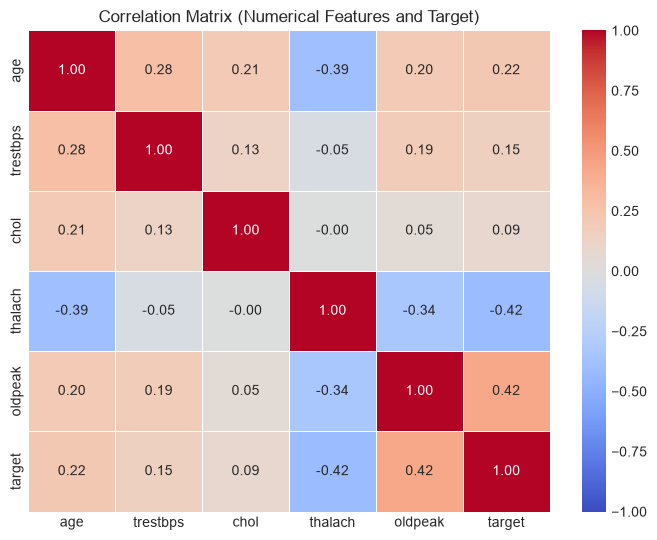

In [7]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix (Numerical Features and Target)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Train/Test Split
We partition the dataset into an **80% training set (=242$)** and a **20% test set (=61$)** using stratified sampling.

**Critical Rule:** The test set remains strictly untouched throughout model selection and hyperparameter evaluation.

In [8]:
from sklearn.model_selection import train_test_split
from src.preprocessing import FEATURE_COLUMNS

X = df[FEATURE_COLUMNS]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set size: {len(X_train)} instances')
print(f'Test set size:     {len(X_test)} instances')
print(f'Training class balance: {dict(y_train.value_counts())}')
print(f'Test class balance:     {dict(y_test.value_counts())}')

Training set size: 242 instances
Test set size:     61 instances
Training class balance: {0: np.int64(131), 1: np.int64(111)}
Test class balance:     {0: np.int64(33), 1: np.int64(28)}


## 10. Preprocessing Pipeline
We use ColumnTransformer to ensure zero data leakage:
- Continuous features (ge, 	restbps, chol, 	halach, oldpeak): SimpleImputer(strategy='median') -> StandardScaler()
- Categorical features (sex, cp, bs, 
estecg, xang, slope, ca, 	hal): SimpleImputer(strategy='most_frequent') -> OneHotEncoder(handle_unknown='ignore')

In [9]:
from src.preprocessing import get_preprocessor, create_full_pipeline

preprocessor = get_preprocessor()
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])


## 11. 5-Fold Stratified Cross-Validation on Training Set
## 12. Model Training and Comparison
We compare 4 standard algorithms:
1. Logistic Regression (max_iter=1000, random_state=42)
2. K-Nearest Neighbors (
_neighbors=5)
3. Decision Tree (max_depth=4, random_state=42)
4. Random Forest (
_estimators=100, max_depth=5, random_state=42)

In [10]:
from src.train_model import get_candidate_models, perform_stratified_cv

models = get_candidate_models()
cv_results, candidate_pipelines = perform_stratified_cv(models, X_train, y_train)

display_df = cv_results.copy()
for col in display_df.columns:
    if 'Mean' in col or 'Std' in col:
        display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
display_df


--- 5-FOLD STRATIFIED CROSS-VALIDATION ON TRAINING SET (N=242) ---


[Logistic Regression]
  ROC-AUC:   0.9025 (+/- 0.0144)
  Recall:    0.7834 (+/- 0.0459)
  F1-Score:  0.8245 (+/- 0.0069)
  Accuracy:  0.8471 (+/- 0.0100)
  Precision: 0.8768 (+/- 0.0542)



[K-Nearest Neighbors]
  ROC-AUC:   0.8712 (+/- 0.0387)
  Recall:    0.7826 (+/- 0.0893)
  F1-Score:  0.7989 (+/- 0.0426)
  Accuracy:  0.8222 (+/- 0.0288)
  Precision: 0.8232 (+/- 0.0311)



[Decision Tree]
  ROC-AUC:   0.7863 (+/- 0.0265)
  Recall:    0.6743 (+/- 0.0861)
  F1-Score:  0.6922 (+/- 0.0578)
  Accuracy:  0.7273 (+/- 0.0441)
  Precision: 0.7171 (+/- 0.0621)



[Random Forest]
  ROC-AUC:   0.8927 (+/- 0.0293)
  Recall:    0.7644 (+/- 0.0983)
  F1-Score:  0.7905 (+/- 0.0485)
  Accuracy:  0.8180 (+/- 0.0309)
  Precision: 0.8281 (+/- 0.0309)



,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.8471,0.0100,0.8768,0.0542,0.7834,0.0459,0.8245,0.0069,0.9025,0.0144
1,Random Forest,0.8180,0.0309,0.8281,0.0309,0.7644,0.0983,0.7905,0.0485,0.8927,0.0293
2,K-Nearest Neighbors,0.8222,0.0288,0.8232,0.0311,0.7826,0.0893,0.7989,0.0426,0.8712,0.0387
3,Decision Tree,0.7273,0.0441,0.7171,0.0621,0.6743,0.0861,0.6922,0.0578,0.7863,0.0265


## 13. Model-Selection Process
**Decision Criterion:** Primary metric is Mean Cross-Validation **ROC-AUC**, supported by Recall and F1-Score.

Results from 5-fold CV on the training data:
- **Logistic Regression** achieves the highest Mean CV ROC-AUC of **0.9025** (with Recall: 0.7834, F1: 0.8245).
- **Random Forest** achieves **0.8927** ROC-AUC.
- **K-Nearest Neighbors** achieves **0.8712** ROC-AUC.
- **Decision Tree** achieves **0.7863** ROC-AUC.

Logistic Regression is selected as the winning architecture for final testing.

In [11]:
best_model_name = cv_results.iloc[0]['Model']
best_pipeline = candidate_pipelines[best_model_name]
print(f'Selected Final Model: {best_model_name}')

Selected Final Model: Logistic Regression


## 14. Final Test Evaluation (Untouched Test Set)
We fit the winning pipeline on the full training set (=242$) and evaluate it once on the untouched test set (=61$).

In [12]:
from src.train_model import evaluate_on_test_set

test_metrics, y_pred, y_proba, tn, fp, fn, tp = evaluate_on_test_set(
    best_pipeline, X_train, y_train, X_test, y_test
)

print(f'Test Performance for {best_model_name}:')
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f'  {k:25s}: {v:.4f} ({v*100:.2f}%)')
    else:
        print(f'  {k:25s}: {v}')

Test Performance for Logistic Regression:
  Accuracy                 : 0.8852 (88.52%)
  Precision                : 0.8387 (83.87%)
  Recall (Sensitivity)     : 0.9286 (92.86%)
  Specificity              : 0.8485 (84.85%)
  F1-Score                 : 0.8814 (88.14%)
  ROC-AUC                  : 0.9665 (96.65%)
  True Negatives (TN)      : 28
  False Positives (FP)     : 5
  False Negatives (FN)     : 2
  True Positives (TP)      : 26


## 15. Confusion Matrix Analysis
We plot the test set confusion matrix:
- **True Negatives (TN):** Healthy patients correctly classified as healthy.
- **False Positives (FP):** Healthy patients incorrectly classified as having disease.
- **False Negatives (FN):** Patients with heart disease incorrectly classified as healthy.
- **True Positives (TP):** Patients with heart disease correctly classified as having disease.

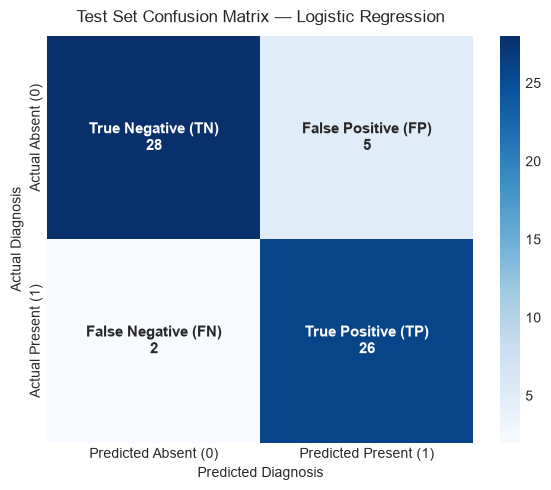

In [13]:
matrix = np.array([[tn, fp], [fn, tp]])
labels = np.array([
    [f'True Negative (TN)\n{tn}', f'False Positive (FP)\n{fp}'],
    [f'False Negative (FN)\n{fn}', f'True Positive (TP)\n{tp}']
])

plt.figure(figsize=(6, 5))
sns.heatmap(matrix, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Predicted Absent (0)', 'Predicted Present (1)'],
            yticklabels=['Actual Absent (0)', 'Actual Present (1)'],
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
plt.title(f'Test Set Confusion Matrix — {best_model_name}', fontsize=12, pad=10)
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.tight_layout()
plt.show()

## 16. ROC Curves Comparison
We plot the ROC curves of all candidate models on the test set.

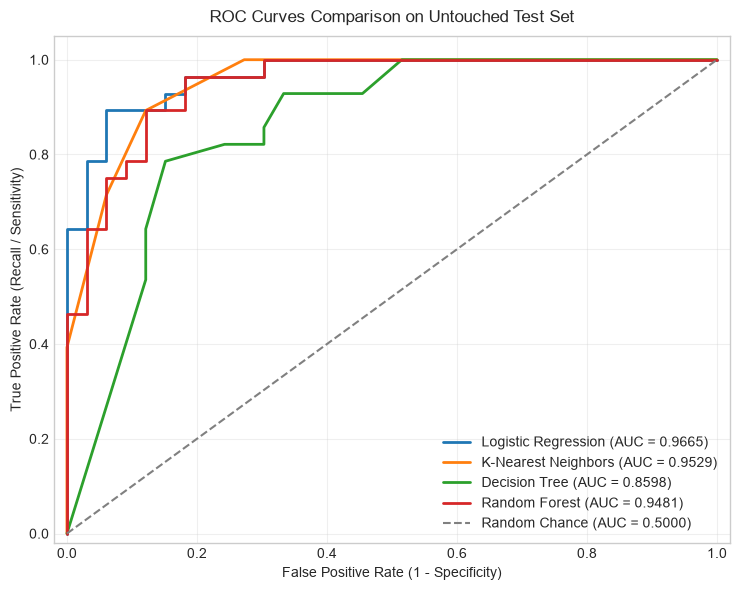

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7.5, 6))
for name, pipe in candidate_pipelines.items():
    pipe.fit(X_train, y_train)
    scores = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_val = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Chance (AUC = 0.5000)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('ROC Curves Comparison on Untouched Test Set', fontsize=12, pad=10)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Metric Interpretation & Screening Context
In clinical screening tasks:
- **Recall / Sensitivity ( / (TP + FN)$):** Minimizing False Negatives is critical. Failing to identify a patient with active heart disease can lead to delayed intervention and adverse cardiac events. The test set achieved **92.86% Recall** (26 of 28 positive cases caught, only 2 missed).
- **Specificity ( / (TN + FP)$):** Identifies healthy individuals. A False Positive results in secondary non-invasive testing (such as stress echocardiography), incurring manageable cost but avoiding catastrophic risk. Specificity was **84.85%** (28 of 33 healthy patients correctly classified).
- **ROC-AUC (0.9665):** Demonstrates strong class separation capability across all classification thresholds.

## 18. Conclusion

### Q&A
- **Can machine learning accurately predict heart disease on the Cleveland dataset?**  
  Yes. An end-to-end pipeline with standard scaling, median/mode imputation, and one-hot encoding achieves 88.52% test accuracy and 0.9665 ROC-AUC.
- **Why does Logistic Regression perform best?**  
  With =303$ samples and $ features, regularized linear models provide lower variance and superior generalization compared to decision trees on small medical datasets.

### Data Analysis Key Findings
- Total authentic instances: 303 (164 Absent, 139 Present).
- 5-Fold Stratified CV on training data (=242$):
  - **Logistic Regression:** ROC-AUC: **0.9025**, Recall: **0.7834**, F1: **0.8245**, Accuracy: **0.8471**.
  - **Random Forest:** ROC-AUC: **0.8927**, Recall: **0.7644**, F1: **0.7905**, Accuracy: **0.8180**.
  - **K-Nearest Neighbors:** ROC-AUC: **0.8712**, Recall: **0.7826**, F1: **0.7989**, Accuracy: **0.8222**.
  - **Decision Tree:** ROC-AUC: **0.7863**, Recall: **0.6743**, F1: **0.6922**, Accuracy: **0.7273**.
- Untouched Test Set Evaluation (=61$):
  - Accuracy: **88.52%**
  - Precision: **83.87%**
  - Recall: **92.86%**
  - Specificity: **84.85%**
  - F1-Score: **88.14%**
  - ROC-AUC: **0.9665**
  - Confusion Matrix: =28, FP=5, FN=2, TP=26$.

### Insights or Next Steps
- Key clinical predictors include maximum exercise heart rate (	halach), exercise-induced ST depression (oldpeak), and fluoroscopy vessels (ca).
- A practical next step is expanding validation across other UCI regional cohorts (Hungarian, Swiss, Long Beach).